In [1]:
import os 
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

from scipy import signal

In [4]:
Data_path = "../data/mit-bih-arrhythmia-database-1.0.0"
record = "100"
lead = 0 

record = wfdb.rdrecord(f"{Data_path}/{record}",channel_names=["MLII", "V5"])
annotation = wfdb.rdann(f"{Data_path}/{record.record_name}", "atr") 

print("Sampling frequency is ", record.fs)
print("Signal shape is" , record.p_signal.shape)
print("Number of annotations is ", len(annotation.sample))


ecg_signal = record.p_signal[:, lead]

print("ECG signal shape:", ecg_signal.shape)
print("Sampling frequency:", record.fs, "Hz")


Sampling frequency is  360
Signal shape is (650000, 2)
Number of annotations is  2274
ECG signal shape: (650000,)
Sampling frequency: 360 Hz


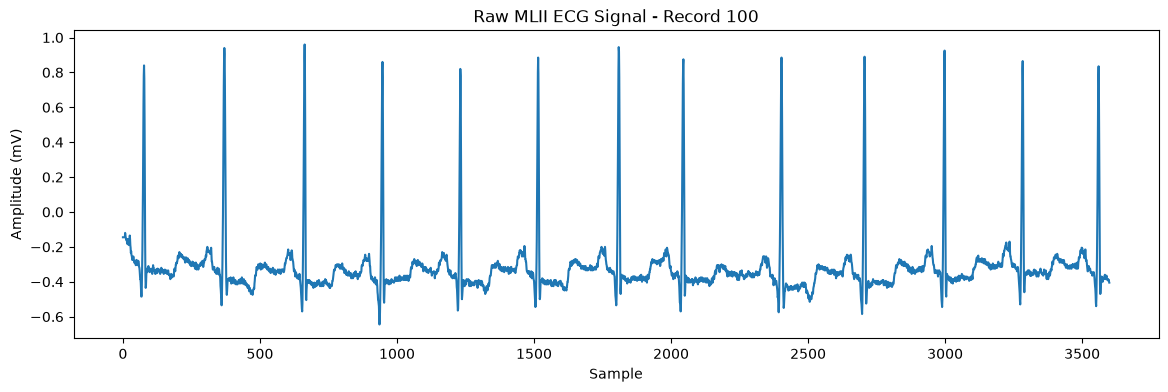

In [5]:

plt.figure(figsize=(14, 4))

plt.plot(ecg_signal[:3600])

plt.xlabel("Sample")
plt.ylabel("Amplitude (mV)")
plt.title("Raw MLII ECG Signal - Record 100")

plt.show()

In [6]:
# Picking one annotated beat to understand the annotation information and actual shape of curve
beat_index = 10
beat_sample = annotation.sample[beat_index]

print("Annotation sample:", beat_sample)
print("Annotation symbol:", annotation.symbol[beat_index])

Annotation sample: 2706
Annotation symbol: N


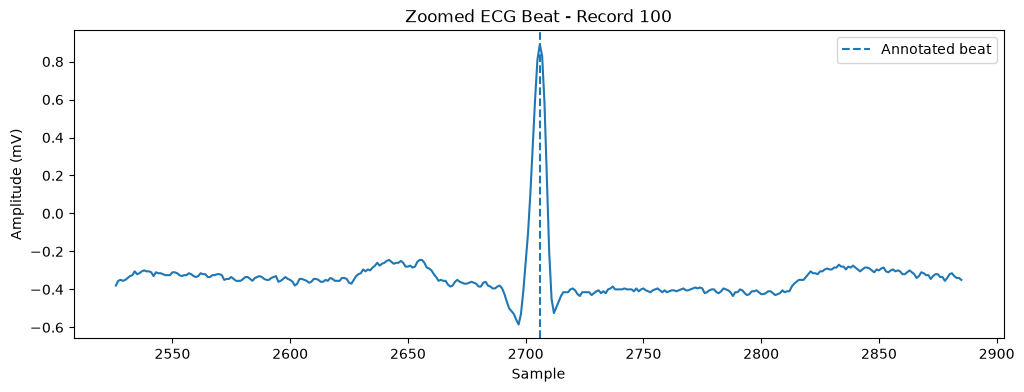

In [7]:
window = 180

start = beat_sample - window
end = beat_sample + window

plt.figure(figsize=(12, 4))

plt.plot(
    np.arange(start, end),
    ecg_signal[start:end]
)

plt.axvline(
    beat_sample,
    linestyle="--",
    label="Annotated beat"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude (mV)")
plt.title("Zoomed ECG Beat - Record 100")
plt.legend()

plt.show()

In [8]:
ecg_segment = ecg_signal[:3600]

print("Number of samples:", len(ecg_segment))
print("Duration:", len(ecg_segment) / record.fs, "seconds")

Number of samples: 3600
Duration: 10.0 seconds


In [17]:
fft_result = np.fft.fft(ecg_segment)

print("FFT output shape:\n", fft_result.shape)
print(fft_result[:10], "\n")  # Print first 10 FFT coefficients

fft_magnitude = np.abs(fft_result)

FFT output shape:
 (3600,)
[-1.15172000e+03 +0.j          3.60413844e+01 +0.33364304j
  4.24465219e+01+15.19304088j -4.91346480e-01 +3.10599058j
  1.21747466e+01-13.29362666j -1.09103323e+00 -2.50008719j
  7.42736968e+00 -3.08961007j  9.73378410e-02 -3.16508029j
  5.11137002e+00 -9.40393248j  1.95936728e+00+14.34827883j] 



In [18]:
frequencies = np.fft.fftfreq(
    len(ecg_segment),
    d=1 / record.fs
)

positive = frequencies >= 0

frequencies_positive = frequencies[positive]
magnitude_positive = fft_magnitude[positive]

In [19]:
frequencies = np.fft.fftfreq(
    len(ecg_segment),
    d=1 / record.fs
)

positive = frequencies >= 0

frequencies_positive = frequencies[positive]
magnitude_positive = fft_magnitude[positive]

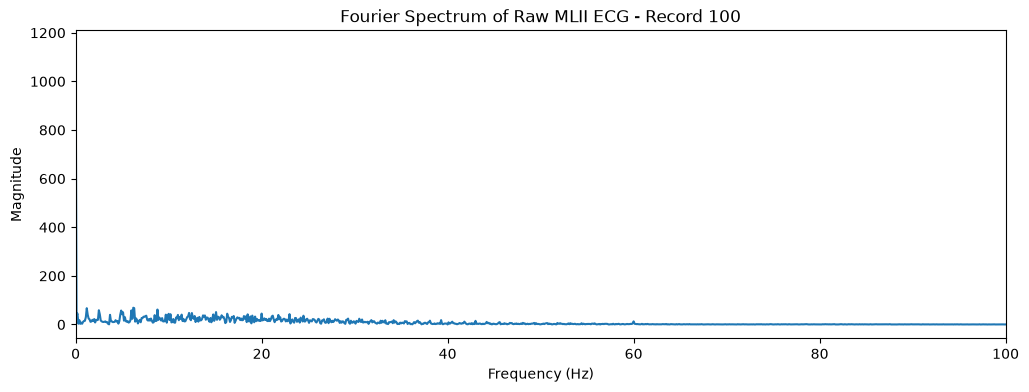

In [20]:
plt.figure(figsize=(12, 4))

plt.plot(
    frequencies_positive,
    magnitude_positive
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Fourier Spectrum of Raw MLII ECG - Record 100")

plt.xlim(0, 100)

plt.show()

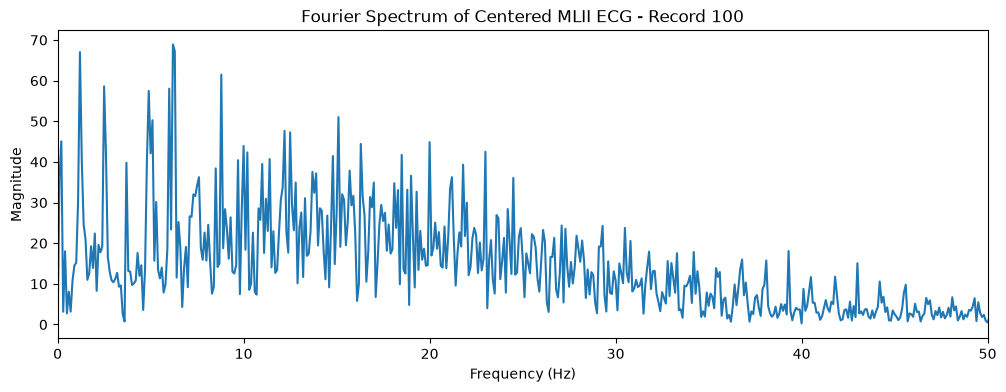

In [21]:
ecg_centered = ecg_segment - np.mean(ecg_segment)

fft_result_centered = np.fft.fft(ecg_centered)

fft_magnitude_centered = np.abs(fft_result_centered)

frequencies = np.fft.fftfreq(
    len(ecg_centered),
    d=1 / record.fs
)

positive = frequencies >= 0

frequencies_positive = frequencies[positive]
magnitude_positive = fft_magnitude_centered[positive]

plt.figure(figsize=(12, 4))

plt.plot(
    frequencies_positive,
    magnitude_positive
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Fourier Spectrum of Centered MLII ECG - Record 100")

plt.xlim(0, 50)

plt.show()